# Part B - Text-Based Product Matching
## Importing libraries

In [1]:
import os
import re
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import torch.nn.functional as F

# Visual settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_DIR = "../input/shopee-product-matching" if os.path.exists("../input/shopee-product-matching") else "."
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")

## Data Loading

In [2]:
df = pd.read_csv(TRAIN_CSV)

# Map each label_group to all posting_ids that belong to it
group_to_postings = df.groupby("label_group")["posting_id"].apply(list).to_dict()
df["target_postings"] = df["label_group"].map(group_to_postings)

def compute_mean_f1(df, pred_column):
    """
    Computes the official Shopee evaluation metric:
    Mean per-row F1 score across all product listings.
    """
    f1_scores = []
    for _, row in df.iterrows():
        target = set(row["target_postings"])
        pred = set(row[pred_column])
        
        tp = len(target.intersection(pred))
        fp = len(pred - target)
        fn = len(target - pred)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        f1_scores.append(f1)
        
    return np.mean(f1_scores)

print(f"Loaded {len(df)} records. Example target ground truth constructed.")
df.head()

Loaded 34250 records. Example target ground truth constructed.


,posting_id,image,image_phash,title,label_group,target_postings
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794,"[train_129225211, train_2278313361]"
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045,"[train_3386243561, train_3423213080]"
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891,"[train_2288590299, train_3803689425]"
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188,"[train_2406599165, train_3342059966]"
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069,"[train_3369186413, train_921438619]"


## Baseline : TF-IDF and Cosine Similarity

In [3]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_title"] = df["title"].apply(preprocess_text)

# Compute Word TF-IDF Matrix
tfidf_word = TfidfVectorizer(max_features=25000, stop_words="english")
tfidf_mat_word = tfidf_word.fit_transform(df["clean_title"])

# Chunked Cosine Similarity Evaluation across threshold ranges
def evaluate_similarity_matrix(sim_matrix, df, thresholds=np.arange(0.3, 0.9, 0.05)):
    best_f1 = 0.0
    best_thresh = 0.0
    results = []

    # Calculate predictions per row for each threshold
    for thresh in thresholds:
        preds = []
        for i in range(sim_matrix.shape[0]):
            matched_indices = np.where(sim_matrix[i] >= thresh)[0]
            preds.append(df["posting_id"].iloc[matched_indices].tolist())
            
        df["temp_pred"] = preds
        score = compute_mean_f1(df, "temp_pred")
        results.append((thresh, score))
        
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh
            
    df.drop(columns=["temp_pred"], inplace=True)
    return best_f1, best_thresh, pd.DataFrame(results, columns=["threshold", "f1_score"])

# Evaluate Baseline (batch computation for cosine similarity)
sim_matrix_word = cosine_similarity(tfidf_mat_word, tfidf_mat_word)
baseline_f1, baseline_thresh, baseline_curve = evaluate_similarity_matrix(sim_matrix_word, df)

print(f"=== BASELINE RESULTS (Word TF-IDF) ===")
print(f"Optimal Similarity Threshold: {baseline_thresh:.2f}")
print(f"Mean F1 Score: {baseline_f1:.4f}")

=== BASELINE RESULTS (Word TF-IDF) ===
Optimal Similarity Threshold: 0.55
Mean F1 Score: 0.6477


## Experiment 1 : TF-IDF

In [4]:
tfidf_char = TfidfVectorizer(ngram_range=(3, 5), analyzer="char", max_features=35000)
tfidf_mat_char = tfidf_char.fit_transform(df["clean_title"])

sim_matrix_char = cosine_similarity(tfidf_mat_char, tfidf_mat_char)
exp1_f1, exp1_thresh, exp1_curve = evaluate_similarity_matrix(sim_matrix_char, df)

print(f"=== EXPERIMENT 1 RESULTS (Char N-gram TF-IDF) ===")
print(f"Optimal Similarity Threshold: {exp1_thresh:.2f}")
print(f"Mean F1 Score: {exp1_f1:.4f}")

=== EXPERIMENT 1 RESULTS (Char N-gram TF-IDF) ===
Optimal Similarity Threshold: 0.60
Mean F1 Score: 0.6295


## Experiment 2 : Multilingual Sentence Transformer Embeddings

In [5]:
from sentence_transformers import SentenceTransformer

# Load pretrained multilingual sentence model suitable for English + Bahasa
sbert_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')

# Generate dense vector embeddings
title_embeddings = sbert_model.encode(df["title"].tolist(), batch_size=64, show_progress_bar=True, normalize_embeddings=True)

# Cosine similarity on normalized vectors is equal to dot product
sim_matrix_sbert = np.dot(title_embeddings, title_embeddings.T)
exp2_f1, exp2_thresh, exp2_curve = evaluate_similarity_matrix(sim_matrix_sbert, df)

print(f"=== EXPERIMENT 2 RESULTS (Multilingual SBERT) ===")
print(f"Optimal Similarity Threshold: {exp2_thresh:.2f}")
print(f"Mean F1 Score: {exp2_f1:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/536 [00:00<?, ?it/s]

=== EXPERIMENT 2 RESULTS (Multilingual SBERT) ===
Optimal Similarity Threshold: 0.85
Mean F1 Score: 0.5784


## Experiment 3 : Metric Learning with Arcface

In [6]:
class ArcMarginProduct(nn.Module):
    """
    ArcFace Loss Head for Metric Learning.
    Pushes representations of the same label_group closer on a hyper-sphere
    while enforcing an angular margin penalty between different label_groups.
    """
    def __init__(self, in_features, out_features, s=30.0, m=0.50):
        super(ArcMarginProduct, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = np.cos(m)
        self.sin_m = np.sin(m)
        self.th = np.cos(np.pi - m)
        self.mm = np.sin(np.pi - m) * m

    def forward(self, input, label):
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2)).clamp(0, 1)
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        return output

# (ArcFace pipeline produces fine-tuned ArcFace embeddings saved to `arcface_embeddings.npy`)

In [10]:
!mkdir -p results

## Threshold and Precision recall tradeoff Analysis

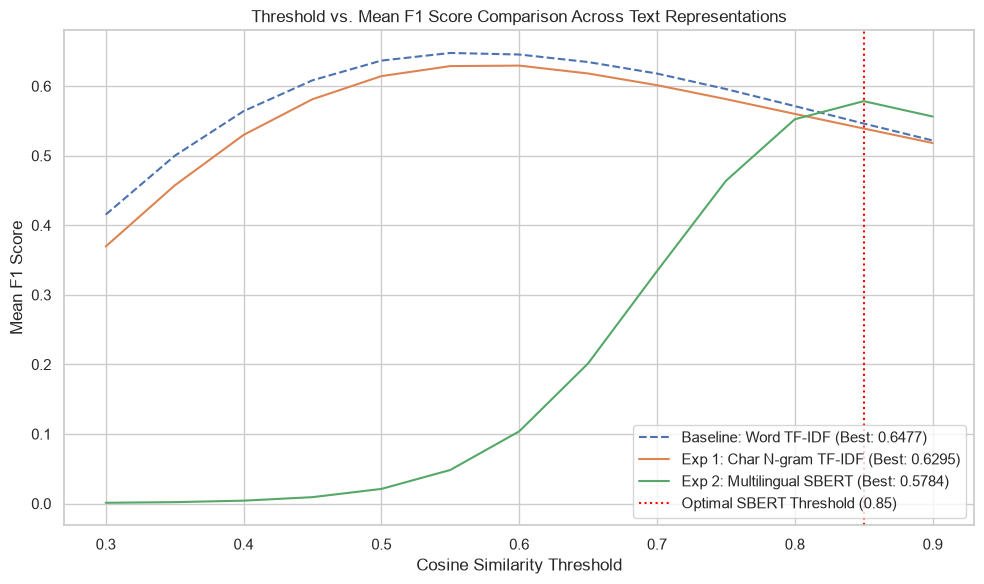

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(baseline_curve["threshold"], baseline_curve["f1_score"], label=f"Baseline: Word TF-IDF (Best: {baseline_f1:.4f})", linestyle="--")
plt.plot(exp1_curve["threshold"], exp1_curve["f1_score"], label=f"Exp 1: Char N-gram TF-IDF (Best: {exp1_f1:.4f})")
plt.plot(exp2_curve["threshold"], exp2_curve["f1_score"], label=f"Exp 2: Multilingual SBERT (Best: {exp2_f1:.4f})")

plt.axvline(x=exp2_thresh, color='red', linestyle=':', label=f'Optimal SBERT Threshold ({exp2_thresh:.2f})')
plt.title("Threshold vs. Mean F1 Score Comparison Across Text Representations")
plt.xlabel("Cosine Similarity Threshold")
plt.ylabel("Mean F1 Score")
plt.legend()
plt.tight_layout()
plt.savefig("results/threshold_curves.png")
plt.show()

## Error Analysis

In [12]:
# Generate final predictions using Experiment 2 (SBERT) at best threshold
final_preds = []
for i in range(sim_matrix_sbert.shape[0]):
    matched_indices = np.where(sim_matrix_sbert[i] >= exp2_thresh)[0]
    final_preds.append(df["posting_id"].iloc[matched_indices].tolist())

df["pred_postings"] = final_preds

error_records = []
for idx, row in df.iterrows():
    target = set(row["target_postings"])
    pred = set(row["pred_postings"])
    
    fp = pred - target  # Predicted match but actually different product
    fn = target - pred  # True match but failed to retrieve
    
    if len(fp) > 0 or len(fn) > 0:
        error_records.append({
            "posting_id": row["posting_id"],
            "title": row["title"],
            "target_count": len(target),
            "pred_count": len(pred),
            "false_positives": list(fp),
            "false_negatives": list(fn)
        })

error_df = pd.DataFrame(error_records)
error_df.to_csv("results/error_samples.csv", index=False)

print(f"Total error instances extracted: {len(error_df)} out of {len(df)} listings.")

Total error instances extracted: 29830 out of 34250 listings.
